# Cat vs Dog Classification with Pure CNN

This notebook implements a pure CNN (no pretrained models) for classifying cats and dogs using the Hugging Face dataset `microsoft/cats_vs_dogs`.

**Key Features:**
- Pure CNN architecture (no ResNet, VGG, etc.)
- Data augmentation to prevent overfitting
- Early stopping and learning rate scheduling
- Data balancing with weighted sampling
- T4 GPU optimized: AMP, larger batch (64), larger images (224)
- Target: >90% validation accuracy

In [1]:
# Install required packages
# !pip install datasets torchvision matplotlib numpy pandas

In [2]:
# Cat vs Dog with pure CNN (no pretrained model)

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image, ImageFile

# Hugging Face datasets
from datasets import load_dataset

# Allow loading slightly corrupted/truncated images instead of crashing workers
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [3]:
# -----------------------------
# 1) Reproducibility and device
# -----------------------------

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# T4 GPU optimizations
USE_AMP = device.type == "cuda"
if USE_AMP:
    from torch.amp import autocast, GradScaler

    scaler = GradScaler('cuda')
    print("Mixed precision (AMP) enabled for T4 GPU")

Device: cuda
Mixed precision (AMP) enabled for T4 GPU


In [4]:
# -----------------------------
# 2) Load dataset from Hugging Face
# -----------------------------

print("Loading dataset from Hugging Face: microsoft/cats_vs_dogs")
dataset = load_dataset("microsoft/cats_vs_dogs")

# Split into train and validation (80% train, 20% validation)
train_val_split = dataset["train"].train_test_split(test_size=0.2, seed=SEED)
train_dataset = train_val_split["train"]
val_dataset = train_val_split["test"]

print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Features: {train_dataset.features}")

Loading dataset from Hugging Face: microsoft/cats_vs_dogs


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/330M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/391M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/23410 [00:00<?, ? examples/s]

Train samples: 18728
Validation samples: 4682
Features: {'image': Image(mode=None, decode=True), 'labels': ClassLabel(names=['cat', 'dog'])}



Class distribution (train):
  class 0 (cat): 9406
  class 1 (dog): 9322

Class distribution (val):
  class 0 (cat): 2335
  class 1 (dog): 2347


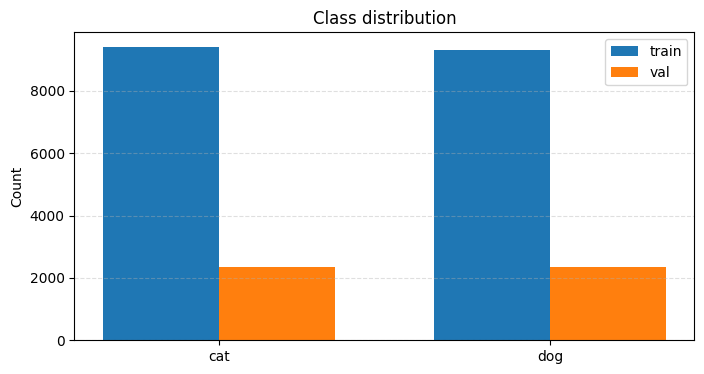

In [5]:
# -----------------------------
# 3) Data analysis
# -----------------------------

# Count class distribution
train_labels = [sample["labels"] for sample in train_dataset]
val_labels = [sample["labels"] for sample in val_dataset]

train_counts = np.bincount(train_labels, minlength=2)
val_counts = np.bincount(val_labels, minlength=2)

class_names = {0: "cat", 1: "dog"}

print("\nClass distribution (train):")
for k in range(2):
    print(f"  class {k} ({class_names[k]}): {train_counts[k]}")

print("\nClass distribution (val):")
for k in range(2):
    print(f"  class {k} ({class_names[k]}): {val_counts[k]}")

# Plot class distribution
plt.figure(figsize=(8, 4))
x = np.array([0, 1])
w = 0.35
plt.bar(x - w / 2, train_counts, width=w, label="train")
plt.bar(x + w / 2, val_counts, width=w, label="val")
plt.xticks(x, ["cat", "dog"])
plt.ylabel("Count")
plt.title("Class distribution")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

In [6]:
# -----------------------------
# 4) Dataset and augmentation
# -----------------------------

IMG_SIZE = 224
BATCH_SIZE = 64

# Multi-worker for GPU (0 for Windows/Jupyter safety)
NUM_WORKERS = 4 if device.type == "cuda" else 0

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ]
)

val_tfms = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ]
)

In [7]:
# -----------------------------
# 5) Custom Dataset class for Hugging Face data
# -----------------------------


class HFCatDogDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.hf_dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        sample = self.hf_dataset[idx]
        image = sample["image"]
        label = sample["labels"]

        # Convert to RGB if needed
        if image.mode != "RGB":
            image = image.convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)


# Create datasets
train_ds = HFCatDogDataset(train_dataset, train_tfms)
val_ds = HFCatDogDataset(val_dataset, val_tfms)

In [8]:
# -----------------------------
# 6) Data balancing
# -----------------------------

train_labels_array = np.array(train_labels)
class_sample_count = np.bincount(train_labels_array, minlength=2)
class_weights = 1.0 / np.maximum(class_sample_count, 1)
sample_weights = class_weights[train_labels_array]
sample_weights = torch.from_numpy(sample_weights).double()

sampler = WeightedRandomSampler(
    weights=sample_weights, num_samples=len(sample_weights), replacement=True
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

num_neg = max(class_sample_count[0], 1)
num_pos = max(class_sample_count[1], 1)
pos_weight = torch.tensor([num_neg / num_pos], dtype=torch.float32, device=device)
print(f"pos_weight for BCEWithLogitsLoss: {pos_weight.item():.4f}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


pos_weight for BCEWithLogitsLoss: 1.0090


In [9]:
# -----------------------------
# 7) Pure CNN model with anti-overfitting
# -----------------------------


class CatDogCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            # Block 2
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            # Block 3
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            # Block 4
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            # Block 5
            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = CatDogCNN().to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3, min_lr=1e-6
)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 1,636,353


In [10]:
# -----------------------------
# 8) Training + anti-overfitting
# -----------------------------

EPOCHS = 40
PATIENCE = 6
best_val_acc = 0.0
best_state = None
no_improve = 0

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}


def run_one_epoch(loader, train_mode=True):
    if train_mode:
        model.train()
    else:
        model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True).unsqueeze(1)

        with torch.set_grad_enabled(train_mode):
            if USE_AMP and train_mode:
                with autocast('cuda'):
                    logits = model(images)
                    loss = criterion(logits, labels)
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=3.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                logits = model(images)
                loss = criterion(logits, labels)
                if train_mode:
                    optimizer.zero_grad()
                    loss.backward()
                    nn.utils.clip_grad_norm_(model.parameters(), max_norm=3.0)
                    optimizer.step()

        probs = torch.sigmoid(logits.float())
        preds = (probs >= 0.5).float()

        running_loss += loss.item() * images.size(0)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / max(total, 1)
    epoch_acc = correct / max(total, 1)
    return epoch_loss, epoch_acc


for epoch in range(EPOCHS):
    train_loss, train_acc = run_one_epoch(train_loader, train_mode=True)
    val_loss, val_acc = run_one_epoch(val_loader, train_mode=False)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    scheduler.step(val_acc)

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}% | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(
                f"Early stopping at epoch {epoch+1} (no val acc improvement for {PATIENCE} epochs)"
            )
            break

if best_state is not None:
    model.load_state_dict(best_state)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 01/40 | Train Loss: 0.6151, Train Acc: 66.20% | Val Loss: 0.6211, Val Acc: 66.04%
Epoch 02/40 | Train Loss: 0.5421, Train Acc: 72.94% | Val Loss: 0.5843, Val Acc: 71.36%
Epoch 03/40 | Train Loss: 0.4980, Train Acc: 76.55% | Val Loss: 0.4518, Val Acc: 79.77%
Epoch 04/40 | Train Loss: 0.4468, Train Acc: 79.78% | Val Loss: 0.6747, Val Acc: 69.37%
Epoch 05/40 | Train Loss: 0.4076, Train Acc: 82.09% | Val Loss: 0.4562, Val Acc: 78.58%
Epoch 06/40 | Train Loss: 0.3790, Train Acc: 83.70% | Val Loss: 0.4317, Val Acc: 81.16%
Epoch 07/40 | Train Loss: 0.3365, Train Acc: 85.57% | Val Loss: 0.3462, Val Acc: 85.16%
Epoch 08/40 | Train Loss: 0.3210, Train Acc: 86.51% | Val Loss: 0.5125, Val Acc: 77.19%
Epoch 09/40 | Train Loss: 0.2892, Train Acc: 88.16% | Val Loss: 0.3588, Val Acc: 83.70%
Epoch 10/40 | Train Loss: 0.2808, Train Acc: 88.57% | Val Loss: 0.2505, Val Acc: 90.05%
Epoch 11/40 | Train Loss: 0.2488, Train Acc: 89.50% | Val Loss: 0.4176, Val Acc: 82.98%
Epoch 12/40 | Train Loss: 0.2345

In [11]:
# -----------------------------
# 9) Final evaluation and plots
# -----------------------------

val_loss, val_acc = run_one_epoch(val_loader, train_mode=False)
print(f"\nBest/Final validation accuracy: {val_acc*100:.2f}%")

# Calculate confusion matrix
tp = tn = fp = fn = 0
model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device).long()
        logits = model(images)
        preds = (torch.sigmoid(logits).squeeze(1) >= 0.5).long()

        tp += int(((preds == 1) & (labels == 1)).sum().item())
        tn += int(((preds == 0) & (labels == 0)).sum().item())
        fp += int(((preds == 1) & (labels == 0)).sum().item())
        fn += int(((preds == 0) & (labels == 1)).sum().item())

precision = tp / max(tp + fp, 1)
recall = tp / max(tp + fn, 1)
f1 = 2 * precision * recall / max(precision + recall, 1e-8)

print("\nConfusion matrix counts:")
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")


Best/Final validation accuracy: 96.52%

Confusion matrix counts:
TN=2265, FP=70, FN=93, TP=2254
Precision: 0.9699 | Recall: 0.9604 | F1: 0.9651


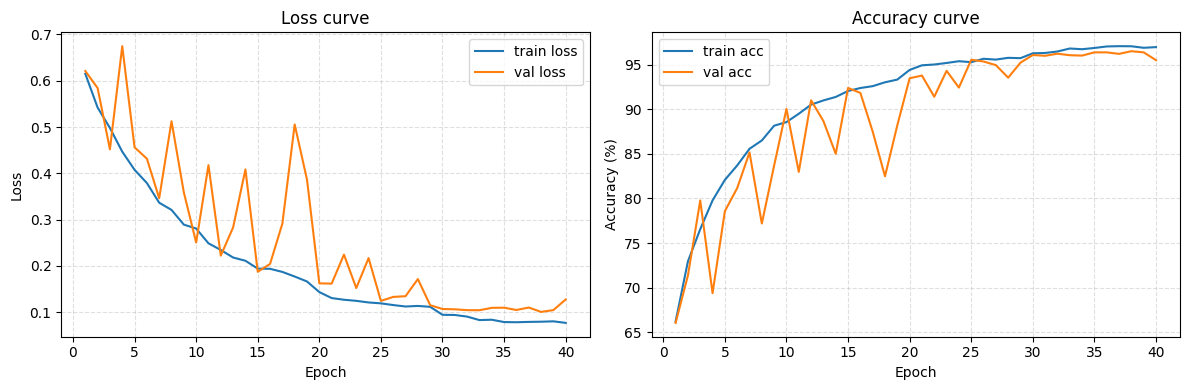

In [12]:
# -----------------------------
# 10) Plot training history
# -----------------------------

epochs_ran = len(history["train_loss"])
x = np.arange(1, epochs_ran + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(x, history["train_loss"], label="train loss")
plt.plot(x, history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss curve")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)

plt.subplot(1, 2, 2)
plt.plot(x, np.array(history["train_acc"]) * 100, label="train acc")
plt.plot(x, np.array(history["val_acc"]) * 100, label="val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy curve")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [13]:
# -----------------------------
# 11) Save model
# -----------------------------

save_path = "catdog_pure_cnn_best.pth"
torch.save(model.state_dict(), save_path)
print(f"Saved best model to: {save_path}")

if val_acc >= 0.90:
    print("Target reached: validation accuracy >= 90%")
else:
    print(
        "Validation accuracy < 90% in this run. Increase epochs, tune lr, or IMG_SIZE/BATCH_SIZE."
    )

Saved best model to: catdog_pure_cnn_best.pth
Target reached: validation accuracy >= 90%


## Summary

This notebook demonstrates:
1. **Pure CNN Architecture**: No pretrained models used
2. **Hugging Face Dataset**: Uses `microsoft/cats_vs_dogs` from Hugging Face
3. **Anti-overfitting Techniques**:
   - Data augmentation (RandomHorizontalFlip, RandomRotation, ColorJitter, RandomAffine)
   - Dropout layers (0.5 and 0.3)
   - Batch normalization
   - Weight decay (L2 regularization)
   - Early stopping
   - Learning rate scheduling
   - Gradient clipping
4. **Data Balancing**: WeightedRandomSampler for balanced training
5. **Target**: Achieve >90% validation accuracy